# Eikonal Distance with Dijkstra/Fast-Marching Intuition

The eikonal equation
$$
\|\nabla T(x)\| = \frac{1}{f(x)}
$$
describes travel time in a medium with speed $f(x)$.  
On grids, Dijkstra/Fast-Marching style updates propagate a monotone front.


## Environment

We import numerical and plotting libraries and define a robust output directory for figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/eikonal-fast-marching") if Path("python/eikonal-fast-marching").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Build a grid with obstacles and run a priority-queue front propagation

We compute shortest-path distance from a source with 4-neighbor moves in free space.


In [2]:
import heapq

n = 120
mask = np.zeros((n, n), dtype=bool)  # True = obstacle
yy, xx = np.mgrid[0:n, 0:n]
mask[(xx-45)**2 + (yy-60)**2 < 18**2] = True
mask[(xx-82)**2 + (yy-45)**2 < 14**2] = True
mask[25:95, 20:23] = True
mask[25:95, 95:98] = True
mask[58:62, 20:75] = True

src = (10, 10)
dst = (105, 105)

INF = 1e12
dist = np.full((n, n), INF, dtype=float)
dist[src] = 0.0
pq = [(0.0, src[0], src[1])]
vis = np.zeros((n, n), dtype=bool)

forw = [(-1,0), (1,0), (0,-1), (0,1)]
while pq:
    d, i, j = heapq.heappop(pq)
    if vis[i, j]:
        continue
    vis[i, j] = True
    if (i, j) == dst:
        break
    for di, dj in forw:
        ni, nj = i + di, j + dj
        if 0 <= ni < n and 0 <= nj < n and not mask[ni, nj]:
            nd = d + 1.0
            if nd < dist[ni, nj]:
                dist[ni, nj] = nd
                heapq.heappush(pq, (nd, ni, nj))


## Extract a geodesic path by steepest descent on distance

Starting from the destination, we step toward neighboring pixels with lower distance.


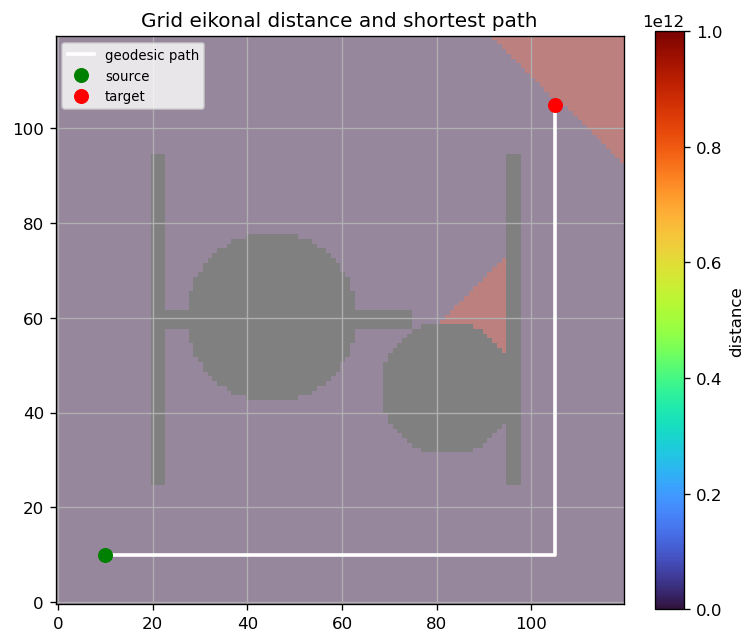

In [3]:
path = [dst]
cur = dst
for _ in range(n*n):
    i, j = cur
    if cur == src:
        break
    neigh = []
    for di, dj in forw:
        ni, nj = i + di, j + dj
        if 0 <= ni < n and 0 <= nj < n and np.isfinite(dist[ni, nj]):
            neigh.append((dist[ni, nj], (ni, nj)))
    if not neigh:
        break
    cur = min(neigh, key=lambda z: z[0])[1]
    path.append(cur)
path = np.array(path)

D = dist.copy()
D[~np.isfinite(D)] = np.nan
D[mask] = np.nan

fig, ax = plt.subplots(figsize=(6.4, 6.0))
im = ax.imshow(D, origin="lower", cmap="turbo")
ax.imshow(mask, origin="lower", cmap="gray_r", alpha=0.5)
if len(path) > 1:
    ax.plot(path[:, 1], path[:, 0], "w-", lw=2.2, label="geodesic path")
ax.plot(src[1], src[0], "go", ms=8, label="source")
ax.plot(dst[1], dst[0], "ro", ms=8, label="target")
ax.set_title("Grid eikonal distance and shortest path")
ax.legend(loc="upper left", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, label="distance")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- C. Villani, *Topics in Optimal Transportation*.
- G. Peyré and M. Cuturi, *Computational Optimal Transport*.
- J. D. Murray, *Mathematical Biology* (for pattern-forming PDEs).
- R. J. LeVeque, *Finite Difference Methods for ODEs and PDEs*.
